# 02 — 探索性数据分析（EDA）

**负责人：组员 2**  
**前提：** 先运行 `01_data_download.ipynb`，确保 Google Drive 里有 `robot_frames.parquet`

**目标：**
1. 理解数据分布（各数据集的规模、reward 分布）
2. 对比高质量 vs 低质量轨迹的差异
3. 分析仿真 vs 真实机器人的特征差异
4. 输出给组员 3 用于报告的图表

In [1]:
# =====================
# Step 0: 安装依赖
# =====================
!pip install matplotlib seaborn pandas pyarrow -q
print('依赖安装完成')

依赖安装完成


In [2]:
# =====================
# Step 1: 挂载 Drive + 加载数据
# =====================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/bigdata-project'
except ImportError:
    DATA_DIR = '../data'

# 加载帧级数据
frames = pd.read_parquet(f'{DATA_DIR}/robot_frames.parquet')
print(f'帧级数据: {frames.shape}')
print(f'数据集: {sorted(frames["source"].unique())}')

帧级数据: (251802, 7)
数据集: ['berkeley_autolab_ur5', 'columbia_cairlab_pusht_real', 'nyu_door_opening_surprising_effectiveness', 'pusht', 'xarm_lift_medium', 'xarm_lift_medium_replay', 'xarm_push_medium', 'xarm_push_medium_replay']


In [3]:
# =====================
# Step 2: 计算 episode 级聚合（快速版）
# 使用 L2 模长聚合，兼容不同维度的数据集
# =====================

frames['state_norm'] = frames['observation_state'].apply(
    lambda x: float(np.linalg.norm(x))
)
frames['action_norm'] = frames['action'].apply(
    lambda x: float(np.linalg.norm(x))
)

# 分组聚合：帧 → episode
episodes = frames.groupby(['source', 'episode_index']).agg(
    episode_length=('frame_index', 'count'),
    state_mean=('state_norm', 'mean'),
    state_std=('state_norm', 'std'),
    action_mean=('action_norm', 'mean'),
    action_std=('action_norm', 'std'),
    max_reward=('next_reward', 'max'),
    avg_reward=('next_reward', 'mean'),
).reset_index()

# 质量标签：per-dataset 中位数
med = episodes.groupby('source')['max_reward'].transform('median')
episodes['quality'] = (episodes['max_reward'] > med).astype(int)
episodes['quality_label'] = episodes['quality'].map({1: 'High', 0: 'Low'})

# Sim vs Real 标签
REAL = {'berkeley_autolab_ur5', 'columbia_cairlab_pusht_real',
        'nyu_door_opening_surprising_effectiveness'}
episodes['is_real'] = episodes['source'].isin(REAL)
episodes['env_type'] = episodes['is_real'].map({True: 'Real', False: 'Sim'})

print(f'Episode 数: {len(episodes):,}')
print(f'高质量: {episodes["quality"].mean():.1%}')
episodes.head(3)

Episode 数: 5,026
高质量: 33.9%


,source,episode_index,episode_length,state_mean,state_std,action_mean,action_std,max_reward,avg_reward,quality,quality_label,is_real,env_type
0,berkeley_autolab_ur5,0,71,1.134767,0.033349,1.000315,0.000142,1.0,0.014085,0,Low,True,Real
1,berkeley_autolab_ur5,1,76,1.115158,0.037374,1.000339,0.000187,1.0,0.013158,0,Low,True,Real
2,berkeley_autolab_ur5,2,81,1.277629,0.200819,0.529199,0.492123,1.0,0.012346,0,Low,True,Real


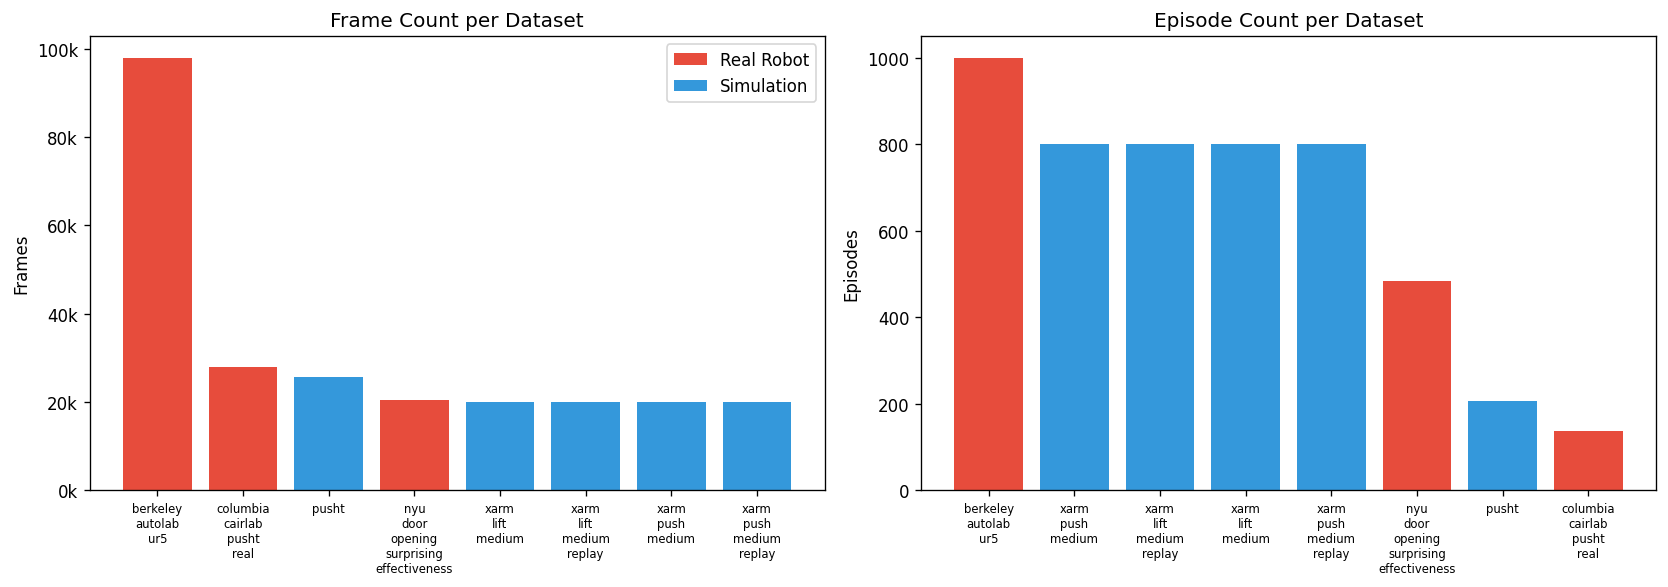

图1 保存完成


In [4]:
# =====================
# 图1: 各数据集帧数和 episode 数
# =====================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 帧数
frame_counts = frames.groupby('source').size().sort_values(ascending=False)
colors = ['#e74c3c' if s in REAL else '#3498db' for s in frame_counts.index]
axes[0].bar(range(len(frame_counts)), frame_counts.values, color=colors)
axes[0].set_xticks(range(len(frame_counts)))
axes[0].set_xticklabels([s.replace('_', '\n') for s in frame_counts.index],
                         fontsize=7, rotation=0)
axes[0].set_title('Frame Count per Dataset', fontsize=12)
axes[0].set_ylabel('Frames')
axes[0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f}k'))

# 图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Real Robot'),
                   Patch(facecolor='#3498db', label='Simulation')]
axes[0].legend(handles=legend_elements, loc='upper right')

# Episode 数
ep_counts = episodes.groupby('source').size().sort_values(ascending=False)
colors2 = ['#e74c3c' if s in REAL else '#3498db' for s in ep_counts.index]
axes[1].bar(range(len(ep_counts)), ep_counts.values, color=colors2)
axes[1].set_xticks(range(len(ep_counts)))
axes[1].set_xticklabels([s.replace('_', '\n') for s in ep_counts.index],
                         fontsize=7, rotation=0)
axes[1].set_title('Episode Count per Dataset', fontsize=12)
axes[1].set_ylabel('Episodes')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig01_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('图1 保存完成')

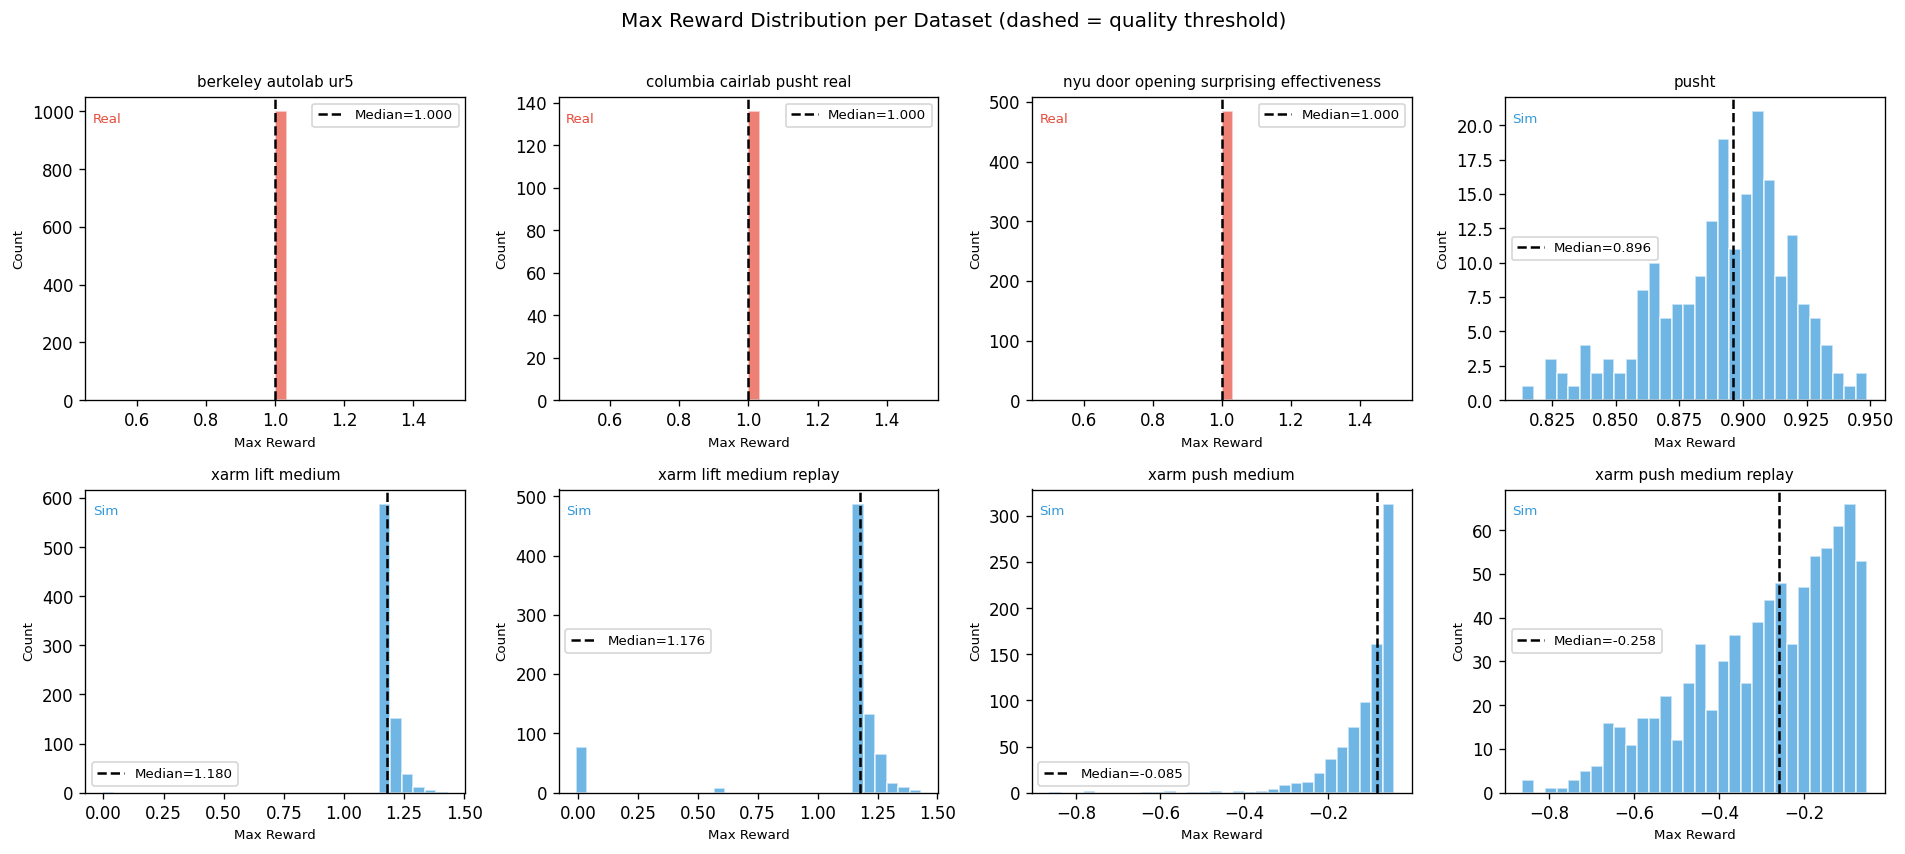

图2 保存完成


In [5]:
# =====================
# 图2: Reward 分布（各数据集）
# =====================

sources = sorted(episodes['source'].unique())
n = len(sources)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.5))
axes = axes.flatten()

for i, source in enumerate(sources):
    sub = episodes[episodes['source'] == source]
    color = '#e74c3c' if source in REAL else '#3498db'
    axes[i].hist(sub['max_reward'], bins=30, color=color, alpha=0.7, edgecolor='white')
    med_val = sub['max_reward'].median()
    axes[i].axvline(med_val, color='black', linestyle='--', linewidth=1.5,
                    label=f'Median={med_val:.3f}')
    axes[i].set_title(source.replace('_', ' '), fontsize=9)
    axes[i].set_xlabel('Max Reward', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)
    axes[i].legend(fontsize=8)
    env = 'Real' if source in REAL else 'Sim'
    axes[i].text(0.02, 0.95, env, transform=axes[i].transAxes,
                 fontsize=8, va='top',
                 color='#e74c3c' if source in REAL else '#3498db')

# 隐藏多余子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Max Reward Distribution per Dataset (dashed = quality threshold)', 
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig02_reward_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('图2 保存完成')

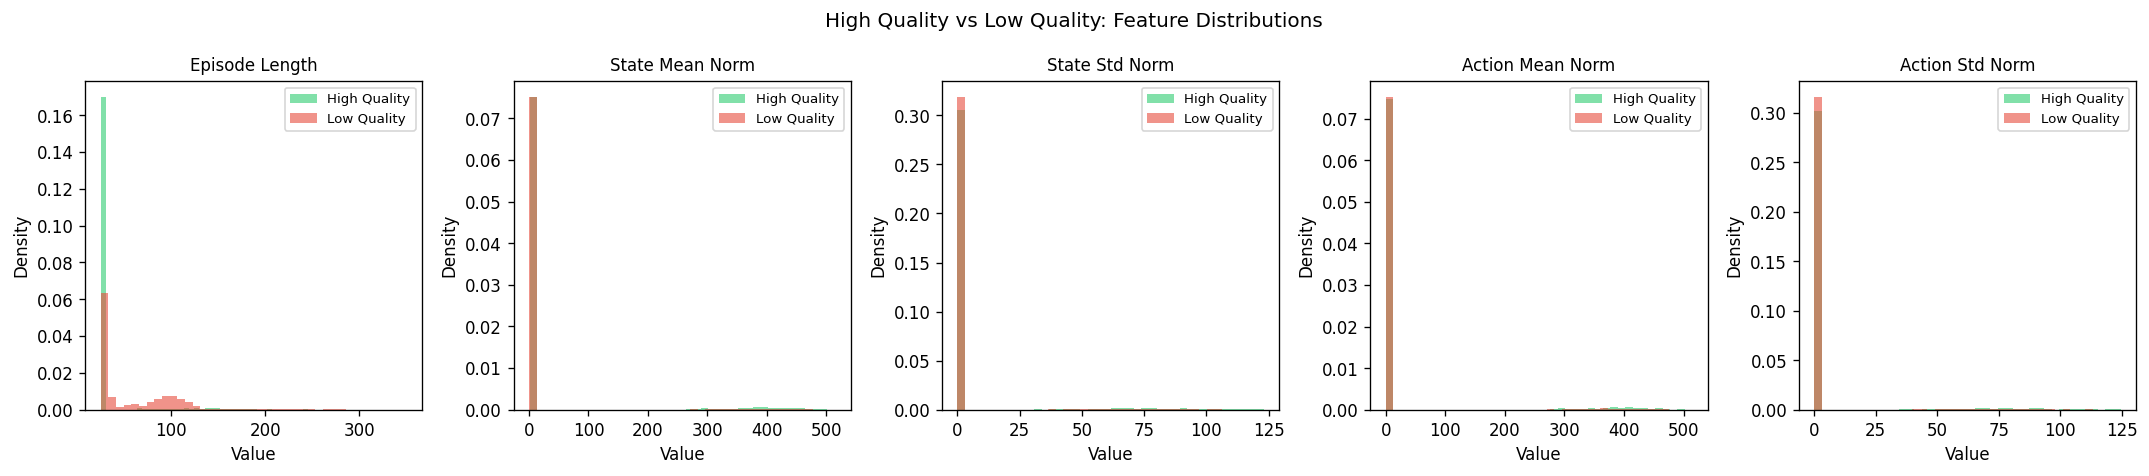

图3 保存完成


In [6]:
# =====================
# 图3: 高质量 vs 低质量 轨迹特征对比
# =====================

features = ['episode_length', 'state_mean', 'state_std',
            'action_mean', 'action_std']
feature_labels = ['Episode Length', 'State Mean Norm',
                  'State Std Norm', 'Action Mean Norm', 'Action Std Norm']

fig, axes = plt.subplots(1, len(features), figsize=(18, 4))

for ax, feat, label in zip(axes, features, feature_labels):
    for q, color, name in [(1, '#2ecc71', 'High Quality'),
                           (0, '#e74c3c', 'Low Quality')]:
        sub = episodes[episodes['quality'] == q][feat].dropna()
        ax.hist(sub, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('High Quality vs Low Quality: Feature Distributions', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig03_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('图3 保存完成')

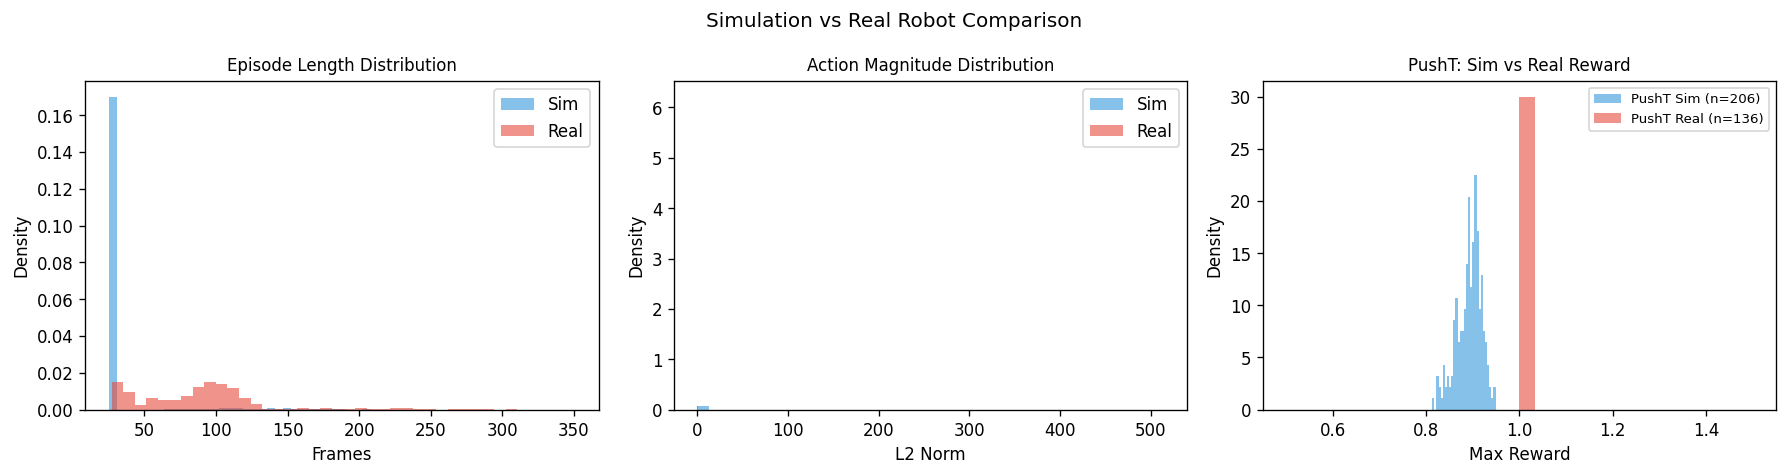

图4 保存完成


In [7]:
# =====================
# 图4: Sim vs Real 对比（Episode 长度 + Action 幅度）
# =====================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Episode 长度
for env, color in [('Sim', '#3498db'), ('Real', '#e74c3c')]:
    sub = episodes[episodes['env_type'] == env]['episode_length']
    axes[0].hist(sub, bins=40, alpha=0.6, color=color, label=env, density=True)
axes[0].set_title('Episode Length Distribution', fontsize=10)
axes[0].set_xlabel('Frames')
axes[0].set_ylabel('Density')
axes[0].legend()

# Action 幅度
for env, color in [('Sim', '#3498db'), ('Real', '#e74c3c')]:
    sub = episodes[episodes['env_type'] == env]['action_mean']
    axes[1].hist(sub, bins=40, alpha=0.6, color=color, label=env, density=True)
axes[1].set_title('Action Magnitude Distribution', fontsize=10)
axes[1].set_xlabel('L2 Norm')
axes[1].set_ylabel('Density')
axes[1].legend()

# PushT: Sim vs Real 直接对比
pusht_sim  = episodes[episodes['source'] == 'pusht']['max_reward']
pusht_real = episodes[episodes['source'] == 'columbia_cairlab_pusht_real']['max_reward']
if len(pusht_sim) > 0 and len(pusht_real) > 0:
    axes[2].hist(pusht_sim,  bins=30, alpha=0.6, color='#3498db',
                 label=f'PushT Sim (n={len(pusht_sim)})', density=True)
    axes[2].hist(pusht_real, bins=30, alpha=0.6, color='#e74c3c',
                 label=f'PushT Real (n={len(pusht_real)})', density=True)
    axes[2].set_title('PushT: Sim vs Real Reward', fontsize=10)
    axes[2].set_xlabel('Max Reward')
    axes[2].set_ylabel('Density')
    axes[2].legend(fontsize=8)

plt.suptitle('Simulation vs Real Robot Comparison', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig04_sim_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('图4 保存完成')

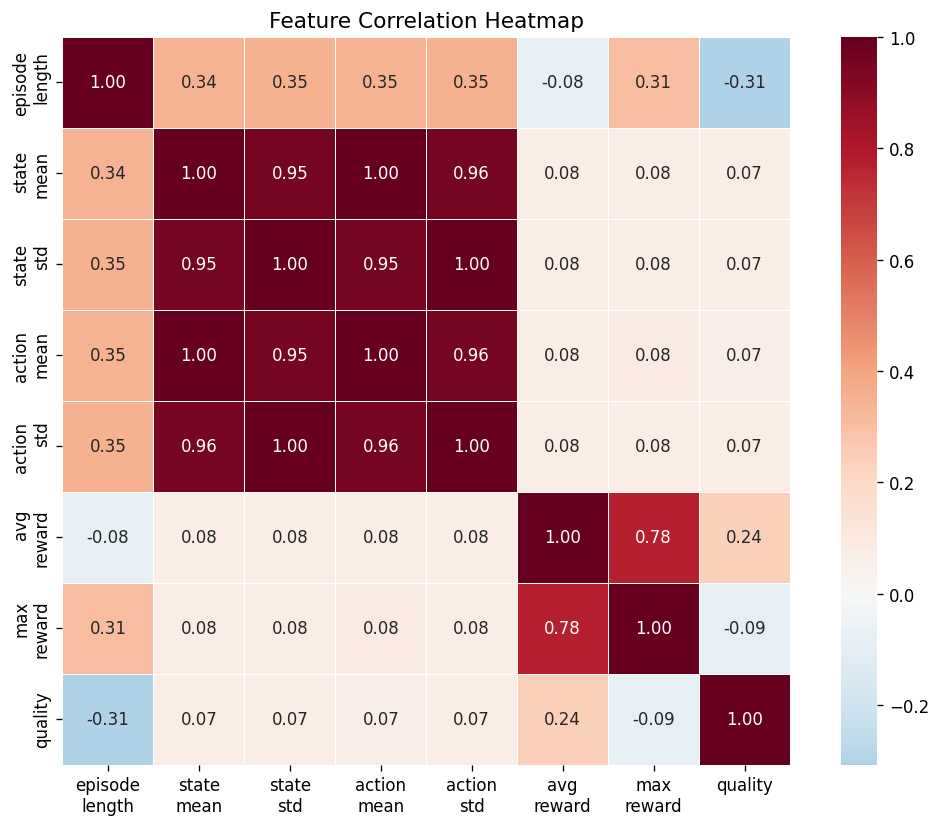

图5 保存完成


In [8]:
# =====================
# 图5: 相关性热力图
# =====================

corr_cols = ['episode_length', 'state_mean', 'state_std',
             'action_mean', 'action_std', 'avg_reward', 'max_reward', 'quality']
corr = episodes[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5,
            xticklabels=[c.replace('_', '\n') for c in corr_cols],
            yticklabels=[c.replace('_', '\n') for c in corr_cols])
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('图5 保存完成')

In [9]:
# =====================
# 统计摘要（用于报告）
# =====================

print('=== 数据集统计摘要（放入报告）===')
print()

summary = episodes.groupby(['source', 'env_type']).agg(
    episodes=('episode_index', 'count'),
    high_quality_rate=('quality', 'mean'),
    avg_episode_len=('episode_length', 'mean'),
    reward_min=('max_reward', 'min'),
    reward_median=('max_reward', 'median'),
    reward_max=('max_reward', 'max'),
).round(3)

print(summary.to_string())
print()

print('总体：')
print(f'  总 episode 数: {len(episodes):,}')
print(f'  高质量率: {episodes["quality"].mean():.1%}')
print(f'  仿真数据: {(~episodes["is_real"]).sum():,} episodes')
print(f'  真实数据: {episodes["is_real"].sum():,} episodes')

=== 数据集统计摘要（放入报告）===

                                                    episodes  high_quality_rate  avg_episode_len  reward_min  reward_median  reward_max
source                                    env_type                                                                                     
berkeley_autolab_ur5                      Real          1000              0.000           97.939       1.000          1.000       1.000
columbia_cairlab_pusht_real               Real           136              0.000          204.471       1.000          1.000       1.000
nyu_door_opening_surprising_effectiveness Real           484              0.000           42.159       1.000          1.000       1.000
pusht                                     Sim            206              0.500          124.515       0.813          0.896       0.949
xarm_lift_medium                          Sim            800              0.499           25.000      -0.003          1.180       1.432
xarm_lift_medium_replay   

In [10]:
# =====================
# 保存 episode 级 DataFrame（供后续 notebook 使用）
# =====================

ep_save_path = f'{DATA_DIR}/episodes_basic.parquet'
episodes.to_parquet(ep_save_path, index=False)
print(f'Episode 级数据已保存: {ep_save_path}')
print(f'形状: {episodes.shape}')
print('下一步: 运行 03_feature_engineering.ipynb 计算 7 个质量指标')

Episode 级数据已保存: ../data/episodes_basic.parquet
形状: (5026, 13)
下一步: 运行 03_feature_engineering.ipynb 计算 7 个质量指标
